# Grass Growth rate Analysis
***
This notebook processes the results of the in-game experiment to determine the rate constant in the logistic growth model of grass. See the markdown file for details about the experiment itself.

## Imports
***

In [11]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp

## Load Data
***
The file `grass_growth.csv` contains two columns. The first is time since the experiment began, and the second is the number of grass blocks in the 30x30 test area. We'll load the file and separate it into two 1D numpy arrays, then divide the second column by 900 to get the grass cover fraction.

In [12]:
with open("grass_growth.csv", "r") as f:
    whole_file = np.loadtxt(f, delimiter=",")

time = whole_file[:, 0]
grass = whole_file[:, 1]
grass_frac = grass/900

## Plot Grass Population vs Time
***
Let's take a moment to go into some more detail about the logistic function. We know its derivative is

$f'(x) = kf(x)(1-f(x))$

But what is the actual expression for f(x)? That expression for f'(x) is a nonlinear ordinary differential equation (nonlinear being synonymous with pain-in-the-neck). Luckily, someone else has already solved it:

$f(x) = \frac{1}{1+e^{-k(x-x_{0})}}$

Where x<sub>0</sub> is a new constant that just shifts the curve left and right.

Here's what f(x) looks like:

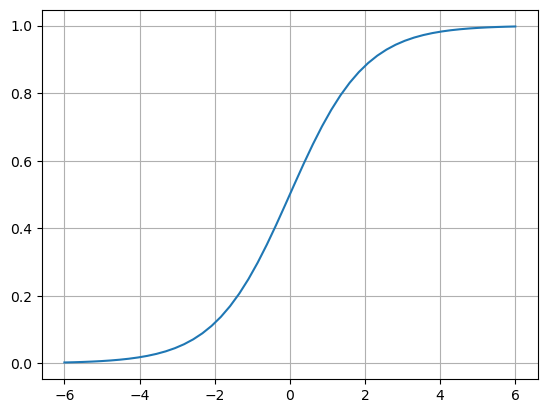

In [35]:
def logistic(x, k, x0):
    return 1/(1 + np.exp(-k * (x - x0)))

f, ax = plt.subplots()

x_example = np.linspace(-6, 6)
y_example = logistic(x_example, 1, 0)

ax.plot(x_example, y_example)
ax.grid(True)

plt.show()

***
If we plot the grass population vs time, we should see something similar:

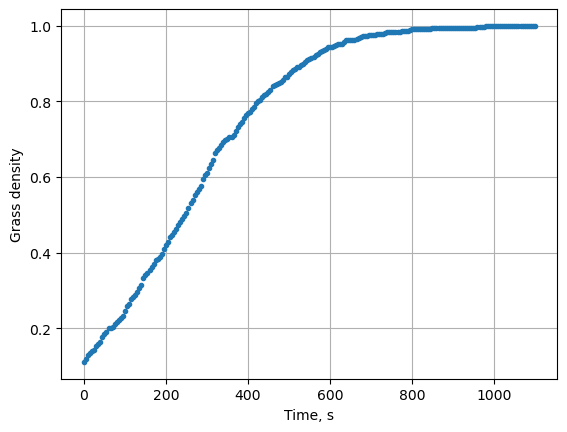

In [14]:
f, ax = plt.subplots()

ax.plot(time, grass_frac, ".")
ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass density")

plt.show()

## Fitting logistic function to grass density
***
We should be able to get a good estimate for k by fitting this expression for f(x) to the grass data. We'll use `scipy.optimize.curve_fit` for this.

We'll need some initial guesses for k and x0. We can estimate x0 from the graph above - at x = x0, f(x) = 0.5. We can also estimate k from the graph - at f(x) = 0.5, f'(x) = 0.25k.

From there, we can call `curve_fit` with the logistic function we defined earlier and the grass data, and get our value for k:

In [21]:
#estimate x0 and k from the graph above
guess = [0.008, 250]

solution = sp.optimize.curve_fit(logistic, time, grass_frac, p0 = guess)

print("x0 = {0}\nk = {1}".format(solution[0][1], solution[0][0]))

x0 = 243.28953052416608
k = 0.007728472838837992


***
Now let's see how the fit lines up:

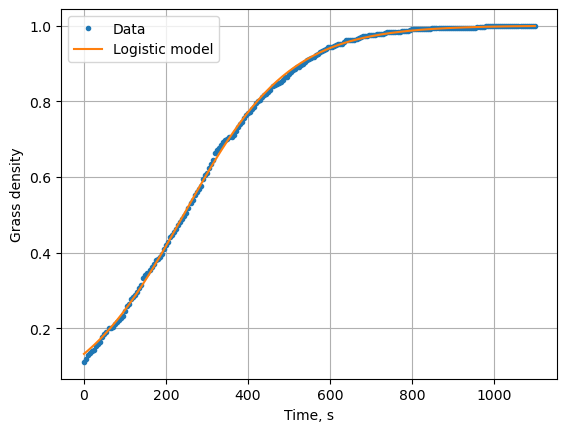

In [34]:
grass_fit = logistic(time, solution[0][0], solution[0][1])

f, ax = plt.subplots()

ax.plot(time, grass_frac, ".", label="Data")
ax.plot(time, grass_fit, "-", label="Logistic model")

ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass density")

ax.legend()

plt.show()

***
Pretty good.

## Fitting logistic derivative to growth rate
***
There's another approach we could take. From the grass density data, we can calculate the grass growth rate and fit the derivative of the logistic function. Ideally, we should get a value for k close to what we got from fitting the grass density data.

We'll start by calculating those derivatives.